# HyDE (Hypothetical Document Embedding) 실험

HyDE(Hypothetical Document Embeddings)는 **사용자 질문에 대해 LLM(대형 언어 모델)로 가상의 문서를 먼저 생성하고, 이 문서를 임베딩하여 검색하는 방식**이다.  
기존에는 질문 자체를 임베딩해 유사한 문서를 찾았지만, HyDE는 질문의 맥락과 의도를 더 잘 반영할 수 있는 가상 문서를 생성해 임베딩하고, 이를 벡터 DB에서 비교함으로써 **더 정확한 검색 결과**를 얻을 수 있다.

**핵심 요약**
- 질문 → LLM이 가상 문서 생성 → 임베딩 → 벡터 DB에서 유사도 검색
- 기존 방식보다 **질문의 의미와 맥락을 더 잘 반영**하여 검색 정확도 향상
- RAG 등 다양한 검색·생성 AI 시스템에서 활용 가능
- 단점: LLM 사용으로 **속도가 느려질 수 있음**

In [1]:
%pip install -Uq python-dotenv langchain langchain-openai langchain-pinecone kiwipiepy rank_bm25 scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_API_KEY'] = os.getenv('langsmith_key')
os.environ['LANGSMITH_PROJECT'] = 'skn23-langchain'
os.environ['OPENAI_API_KEY'] = os.getenv("openai_key")
os.environ['PINECONE_API_KEY'] = os.getenv("pinecone_key")

## 데이터 준비

In [3]:
import pandas as pd

documents_df = pd.read_csv('documents.csv')
queries_df = pd.read_csv('queries.csv')

## BM25

In [4]:
# BM25 키워드 검색 모델
# - 문서를 토큰화해서 BM25모델 생성
# - 검색어도 동일하게 토큰화한 이후 BM25 검색

from rank_bm25 import BM25Okapi
from kiwipiepy import Kiwi

kiwi = Kiwi()

def kiwi_tokenize(doc):
    return [token.form for token in kiwi.tokenize(doc)]

tokenized_docs = [kiwi_tokenize(doc) for doc in documents_df['content']]
bm25 = BM25Okapi(tokenized_docs)

def bm25_search(query, top_k=5):
    query_tokens = kiwi_tokenize(query)
    # print(query_tokens)
    scores = bm25.get_scores(query_tokens) # 30개의 문서에 대한 bm25 점수
    # print(scores)

    ranked_idx = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    retrieved_docs = [documents_df['doc_id'].iloc[i] for i in ranked_idx[:top_k]]
    return retrieved_docs

bm25_search('제주도 관광 명소')

['D1', 'D2', 'D3', 'D4', 'D5']

## 벡터 서치

In [5]:
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

embedding_model = OpenAIEmbeddings()
vector_store = PineconeVectorStore(
    index_name='ir',
    embedding=embedding_model
 )

c:\Users\user\nlp\natural_language_processing\nlp_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## HyDE Chain

In [6]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm = init_chat_model('gpt-4.1-mini', temperature=0.3)
prompt = PromptTemplate.from_template('''
질문: {query}

위 질문에 대해서 실제 문서가 아니어도 좋으니, 답변을 생성하세요.
''')
output_parser = StrOutputParser()

hyde_chain = prompt | llm | output_parser
print(hyde_chain.invoke('제주도 관광 명소'))

제주도는 아름다운 자연경관과 독특한 문화가 어우러진 한국의 대표적인 관광지입니다. 제주도에서 꼭 방문해야 할 관광 명소 몇 곳을 소개합니다.

1. 한라산 국립공원  
제주도의 중심에 위치한 한라산은 한국에서 가장 높은 산으로, 등산과 자연 탐방을 즐기기에 최적의 장소입니다. 사계절 내내 다양한 풍경을 감상할 수 있으며, 특히 봄철의 진달래와 가을철 단풍이 유명합니다.

2. 성산일출봉  
유네스코 세계자연유산으로 지정된 성산일출봉은 제주 동쪽 해안에 위치한 화산 분화구입니다. 정상에서 바라보는 일출은 제주도에서 가장 아름다운 광경 중 하나로 꼽힙니다.

3. 만장굴  
만장굴은 세계에서 가장 긴 용암동굴 중 하나로, 내부에는 다양한 용암 지형과 희귀한 동굴 생태계를 관찰할 수 있습니다. 시원한 동굴 내부는 여름철 관광객들에게 인기입니다.

4. 협재 해수욕장  
맑고 푸른 바다와 하얀 모래사장이 펼쳐진 협재 해수욕장은 가족 단위 관광객과 해양 스포츠를 즐기는 이들에게 사랑받는 장소입니다.

5. 제주 민속촌  
제주의 전통 가옥과 생활 문화를 체험할 수 있는 민속촌에서는 제주 사람들의 옛 생활 방식을 엿볼 수 있습니다. 다양한 전통 행사와 체험 프로그램도 운영됩니다.

6. 우도  
제주 본섬에서 배로 약 15분 거리에 있는 우도는 작은 섬이지만 아름다운 해변과 독특한 자연경관으로 유명합니다. 자전거를 대여해 섬을 한 바퀴 도는 것이 인기입니다.

이 외에도 제주도에는 천지연 폭포, 정방폭포, 용두암, 서귀포 매일올레시장 등 다양한 볼거리와 먹거리가 많으니 여행 계획 시 참고하시기 바랍니다.


In [7]:
# HyDE 가상답변
import time
from tqdm.auto import tqdm

hyde_pseudo = {}

for idx, row in tqdm(queries_df.iterrows()):
    qid = row['query_id']
    query_text = row['query_text']
    pseudo_answer = hyde_chain.invoke(query_text)
    hyde_pseudo[qid] = pseudo_answer
    time.sleep(0.5)

hyde_pseudo

30it [04:02,  8.07s/it]


{'Q1': '제주도 올레길 트레킹 코스를 추천드릴게요!\n\n1. **올레길 7코스 (외돌개 ~ 월평마을)**  \n   - 난이도: 중간  \n   - 특징: 제주 바다와 오름, 숲길을 함께 즐길 수 있는 코스입니다. 외돌개 바위와 푸른 바다가 어우러져 사진 찍기 좋은 명소가 많아요.\n\n2. **올레길 10코스 (쇠소깍 ~ 남원포구)**  \n   - 난이도: 쉬움  \n   - 특징: 해안선을 따라 걷는 코스로, 쇠소깍의 맑은 물과 카약 체험도 할 수 있어 가족 단위 여행객에게 추천합니다.\n\n3. **올레길 1코스 (시흥초등학교 ~ 광치기 해변)**  \n   - 난이도: 중간  \n   - 특징: 제주 올레길의 시작점으로, 성산 일출봉과 광치기 해변의 멋진 경관을 감상할 수 있습니다. 일출 명소로도 유명해요.\n\n4. **올레길 13코스 (서귀포 시내 ~ 대평포구)**  \n   - 난이도: 중간  \n   - 특징: 서귀포 시내를 지나 해안 절경과 함께 올레길의 다양한 풍경을 즐길 수 있습니다. 중간중간 카페와 식당도 많아 편리합니다.\n\n올레길은 총 21개 코스로 구성되어 있어 체력과 일정에 맞춰 선택하시면 좋습니다. 걷는 동안 제주 특유의 자연과 문화를 느낄 수 있어 트레킹 초보자부터 경험자까지 모두 만족할 만한 코스들이 많답니다. 편안한 신발과 충분한 물, 간식을 준비해 즐거운 여행 되세요!',
 'Q2': '전주 비빔밥과 진주 비빔밥은 모두 한국을 대표하는 비빔밥이지만, 재료 구성과 맛에서 차이가 있습니다.\n\n1. 전주 비빔밥  \n- 재료: 전주 비빔밥은 다양한 나물과 고명, 특히 고사리, 콩나물, 도라지, 시금치, 애호박, 고추장, 계란 후라이 또는 날계란, 그리고 육회(생고기)나 불고기가 들어가는 경우가 많습니다. 밥 위에 고명들이 풍성하게 올려져 있고, 참기름과 고추장을 넣어 비벼 먹습니다.  \n- 맛: 전주 비빔밥은 재료가 다양하고 신선하여 고소하고 감칠맛이 풍부하며, 육회나 불고기에서 나오는 고기의 풍미가 더해져 깊은

In [8]:
# 질문/가상답변 확인
import pandas as pd

pd.set_option('display.max_colwidth', None)

hyde_df = pd.DataFrame({
    'query_id': list(hyde_pseudo.keys()),
    'query_text': queries_df['query_text'],
    'pseudo_answer': list(hyde_pseudo.values())

})
hyde_df.head()

,query_id,query_text,pseudo_answer
0,Q1,제주도 올레길 트레킹 코스 추천,"제주도 올레길 트레킹 코스를 추천드릴게요!\n\n1. **올레길 7코스 (외돌개 ~ 월평마을)** \n - 난이도: 중간 \n - 특징: 제주 바다와 오름, 숲길을 함께 즐길 수 있는 코스입니다. 외돌개 바위와 푸른 바다가 어우러져 사진 찍기 좋은 명소가 많아요.\n\n2. **올레길 10코스 (쇠소깍 ~ 남원포구)** \n - 난이도: 쉬움 \n - 특징: 해안선을 따라 걷는 코스로, 쇠소깍의 맑은 물과 카약 체험도 할 수 있어 가족 단위 여행객에게 추천합니다.\n\n3. **올레길 1코스 (시흥초등학교 ~ 광치기 해변)** \n - 난이도: 중간 \n - 특징: 제주 올레길의 시작점으로, 성산 일출봉과 광치기 해변의 멋진 경관을 감상할 수 있습니다. 일출 명소로도 유명해요.\n\n4. **올레길 13코스 (서귀포 시내 ~ 대평포구)** \n - 난이도: 중간 \n - 특징: 서귀포 시내를 지나 해안 절경과 함께 올레길의 다양한 풍경을 즐길 수 있습니다. 중간중간 카페와 식당도 많아 편리합니다.\n\n올레길은 총 21개 코스로 구성되어 있어 체력과 일정에 맞춰 선택하시면 좋습니다. 걷는 동안 제주 특유의 자연과 문화를 느낄 수 있어 트레킹 초보자부터 경험자까지 모두 만족할 만한 코스들이 많답니다. 편안한 신발과 충분한 물, 간식을 준비해 즐거운 여행 되세요!"
1,Q2,전주 비빔밥 vs 진주 비빔밥 재료 및 맛 차이,"전주 비빔밥과 진주 비빔밥은 모두 한국을 대표하는 비빔밥이지만, 재료 구성과 맛에서 차이가 있습니다.\n\n1. 전주 비빔밥 \n- 재료: 전주 비빔밥은 다양한 나물과 고명, 특히 고사리, 콩나물, 도라지, 시금치, 애호박, 고추장, 계란 후라이 또는 날계란, 그리고 육회(생고기)나 불고기가 들어가는 경우가 많습니다. 밥 위에 고명들이 풍성하게 올려져 있고, 참기름과 고추장을 넣어 비벼 먹습니다. \n- 맛: 전주 비빔밥은 재료가 다양하고 신선하여 고소하고 감칠맛이 풍부하며, 육회나 불고기에서 나오는 고기의 풍미가 더해져 깊은 맛을 냅니다. 고추장의 매콤함과 참기름의 고소함이 잘 어우러져 균형 잡힌 맛이 특징입니다.\n\n2. 진주 비빔밥 \n- 재료: 진주 비빔밥은 전주 비빔밥보다 고명이 더 다양하고 정교한 편입니다. 주로 소고기 육전(얇게 저민 고기 전), 표고버섯, 오이, 고사리, 숙주나물, 무생채, 계란 지단 등이 들어갑니다. 특히 육전이 들어가는 것이 큰 특징이며, 고추장 대신 간장 양념을 사용하는 경우도 많습니다. \n- 맛: 진주 비빔밥은 간장 양념을 사용해 전주 비빔밥보다 덜 맵고 담백한 맛이 납니다. 육전과 각종 나물에서 나오는 고소하고 깔끔한 맛이 조화를 이루며, 전체적으로 부드럽고 깔끔한 맛이 특징입니다.\n\n요약하자면, 전주 비빔밥은 고추장과 육회가 어우러진 진한 맛과 풍성한 고명이 특징이고, 진주 비빔밥은 육전과 간장 양념으로 담백하고 깔끔한 맛을 내는 것이 차이점입니다. 두 비빔밥 모두 지역 특색이 잘 반영된 맛있는 한식입니다."
2,Q3,걸스데이 대표 히트곡 목록 알려줘,"걸스데이(Girl's Day)는 대한민국의 인기 걸그룹으로, 여러 히트곡을 통해 많은 사랑을 받았습니다. 대표적인 히트곡 목록은 다음과 같습니다:\n\n1. **기대해 (Expect)** (2013) \n 걸스데이의 대표곡 중 하나로, 밝고 경쾌한 멜로디가 인상적인 곡입니다.\n\n2. **Something** (2014) \n 섹시하고 성숙한 콘셉트로 큰 인기를 끌었으며, 걸스데이의 전성기를 이끈 곡입니다.\n\n3. **Darling** (2014) \n 사랑스러운 분위기의 곡으로 팬들에게 많은 사랑을 받았습니다.\n\n4. **Ring My Bell** (2015) \n 청량하고 신나는 사운드가 특징인 곡입니다.\n\n5. **Female President (여자 대통령)** (2013) \n 걸스데이만의 당당하고 강렬한 매력을 보여준 곡입니다.\n\n이 외에도 걸스데이는 다양한 곡들로 활동하며 많은 팬들의 사랑을 받았습니다."
3,Q4,훈민정음 창제 배경과 세종대왕의 의의,"훈민정음 창제 배경과 세종대왕의 의의에 대해 설명드리겠습니다.\n\n훈민정음은 15세기 조선 시대 세종대왕이 백성들의 문자 생활을 돕기 위해 창제한 한글의 원래 이름입니다. 당시 조선은 한자를 공식 문자로 사용하고 있었는데, 한자는 배우기 어렵고 복잡하여 일반 백성들이 글을 익히기 힘들었습니다. 이로 인해 지식과 정보가 양반 계층에만 국한되고, 평민들은 자신의 생각을 글로 표현하거나 기록하는 데 큰 어려움을 겪었습니다.\n\n세종대왕은 이러한 문제를 해결하고자 모든 백성이 쉽게 배우고 쓸 수 있는 새로운 문자 체계를 만들기로 결심했습니다. 1443년에 훈민정음을 창제하여 1446년에 반포하였으며, 이는 ‘백성을 가르치는 바른 소리’라는 뜻을 담고 있습니다. 훈민정음은 자음과 모음이 체계적으로 결합되어 발음 원리를 과학적으로 반영한 문자로, 배우기 쉽고 쓰기 편리한 특징을 가지고 있습니다.\n\n세종대왕의 의의는 단순히 새로운 문자를 만든 데 그치지 않고, 이를 통해 백성들의 문해력을 높이고 사회적 평등을 증진시키려 한 데 있습니다. 훈민정음은 한국어를 정확히 표현할 수 있는 문자로서 문화 발전과 민족 정체성 확립에 큰 기여를 했습니다. 또한 세종대왕은 학문과 과학 기술을 장려하며 조선의 문화와 정치 발전에 중대한 영향을 끼친 위대한 군주로 평가받고 있습니다."
4,Q5,이순신 장군이 명량 해전에서 사용한 전술은 무엇인가?,"이순신 장군이 명량 해전에서 사용한 전술은 주로 지형과 조류의 특성을 활용한 '기습 및 집중 공격' 전략입니다. 명량 해전은 좁고 급류가 흐르는 명량 해협에서 벌어졌는데, 이순신 장군은 이 지형적 이점을 최대한 활용하여 적의 대규모 함대를 효과적으로 분산시키고, 조류가 빠른 구간에서 적의 움직임을 제한했습니다. 또한, 그는 거북선과 판옥선 등 강력한 전투함을 중심으로 적의 진형을 집중 공격하여 혼란을 야기하고, 빠른 기동력과 화력을 이용해 적을 차례로 격파하는 전술을 구사했습니다. 이 전술 덕분에 수적으로 열세였던 조선 수군이 대승을 거둘 수 있었습니다."


In [9]:
# hyde 검색
hyde_results = {}
for idx, row in hyde_df.iterrows():
    qid = row['query_id']
    query_text = row['query_text']
    pseudo_answer = row['pseudo_answer']
    docs = vector_store.similarity_search(pseudo_answer, k=5)
    hyde_results[qid] = [doc.metadata['doc_id'] for doc in docs]
hyde_results

{'Q1': ['D12', 'D1', 'D8', 'D15', 'D10'],
 'Q2': ['D13', 'D2', 'D16', 'D12', 'D1'],
 'Q3': ['D3', 'D9', 'D1', 'D15', 'D12'],
 'Q4': ['D4', 'D5', 'D15', 'D9', 'D2'],
 'Q5': ['D5', 'D4', 'D23', 'D15', 'D2'],
 'Q6': ['D6', 'D26', 'D25', 'D17', 'D14'],
 'Q7': ['D25', 'D7', 'D14', 'D26', 'D1'],
 'Q8': ['D8', 'D12', 'D15', 'D18', 'D30'],
 'Q9': ['D9', 'D15', 'D1', 'D4', 'D3'],
 'Q10': ['D10', 'D4', 'D1', 'D3', 'D15'],
 'Q11': ['D11', 'D1', 'D12', 'D16', 'D26'],
 'Q12': ['D12', 'D1', 'D8', 'D13', 'D11'],
 'Q13': ['D13', 'D2', 'D16', 'D11', 'D12'],
 'Q14': ['D14', 'D26', 'D7', 'D25', 'D6'],
 'Q15': ['D15', 'D9', 'D16', 'D4', 'D3'],
 'Q16': ['D16', 'D2', 'D9', 'D4', 'D15'],
 'Q17': ['D17', 'D1', 'D12', 'D9', 'D10'],
 'Q18': ['D18', 'D26', 'D4', 'D21', 'D11'],
 'Q19': ['D19', 'D23', 'D22', 'D20', 'D28'],
 'Q20': ['D20', 'D18', 'D19', 'D22', 'D23'],
 'Q21': ['D21', 'D23', 'D18', 'D30', 'D15'],
 'Q22': ['D22', 'D23', 'D20', 'D24', 'D19'],
 'Q23': ['D23', 'D24', 'D22', 'D20', 'D15'],
 'Q24': ['D24'

In [10]:
bm25_results = {}
for idx, row in queries_df.iterrows():
    qid = row['query_id']
    query_text = row['query_text']
    bm25_results[qid] = bm25_search(query_text, top_k=5)
bm25_results

{'Q1': ['D1', 'D2', 'D3', 'D4', 'D5'],
 'Q2': ['D13', 'D2', 'D1', 'D3', 'D4'],
 'Q3': ['D2', 'D21', 'D14', 'D11', 'D28'],
 'Q4': ['D4', 'D9', 'D1', 'D30', 'D5'],
 'Q5': ['D5', 'D18', 'D19', 'D23', 'D15'],
 'Q6': ['D6', 'D27', 'D17', 'D25', 'D3'],
 'Q7': ['D27', 'D25', 'D7', 'D14', 'D9'],
 'Q8': ['D8', 'D18', 'D30', 'D12', 'D29'],
 'Q9': ['D9', 'D27', 'D1', 'D2', 'D3'],
 'Q10': ['D10', 'D3', 'D9', 'D17', 'D25'],
 'Q11': ['D11', 'D4', 'D14', 'D28', 'D26'],
 'Q12': ['D12', 'D8', 'D9', 'D27', 'D5'],
 'Q13': ['D13', 'D14', 'D26', 'D2', 'D3'],
 'Q14': ['D14', 'D7', 'D25', 'D27', 'D26'],
 'Q15': ['D9', 'D15', 'D26', 'D14', 'D1'],
 'Q16': ['D16', 'D15', 'D9', 'D29', 'D8'],
 'Q17': ['D17', 'D25', 'D6', 'D3', 'D10'],
 'Q18': ['D18', 'D4', 'D28', 'D5', 'D7'],
 'Q19': ['D19', 'D18', 'D14', 'D24', 'D29'],
 'Q20': ['D20', 'D27', 'D10', 'D3', 'D4'],
 'Q21': ['D21', 'D19', 'D25', 'D2', 'D11'],
 'Q22': ['D22', 'D7', 'D23', 'D19', 'D18'],
 'Q23': ['D23', 'D26', 'D24', 'D22', 'D19'],
 'Q24': ['D24', 'D23

In [11]:
dense_results = {}
for idx, row in queries_df.iterrows():
    qid = row['query_id']
    query_text = row['query_text']
    docs = vector_store.similarity_search(query_text, k=5)
    dense_results[qid] = [doc.metadata['doc_id'] for doc in docs]
dense_results

{'Q1': ['D12', 'D1', 'D8', 'D26', 'D17'],
 'Q2': ['D13', 'D2', 'D16', 'D12', 'D5'],
 'Q3': ['D3', 'D9', 'D17', 'D15', 'D12'],
 'Q4': ['D4', 'D5', 'D1', 'D9', 'D2'],
 'Q5': ['D5', 'D4', 'D15', 'D2', 'D16'],
 'Q6': ['D6', 'D25', 'D26', 'D17', 'D1'],
 'Q7': ['D25', 'D7', 'D14', 'D26', 'D10'],
 'Q8': ['D8', 'D12', 'D15', 'D26', 'D4'],
 'Q9': ['D9', 'D15', 'D1', 'D3', 'D12'],
 'Q10': ['D10', 'D4', 'D1', 'D3', 'D5'],
 'Q11': ['D11', 'D2', 'D13', 'D1', 'D12'],
 'Q12': ['D12', 'D1', 'D8', 'D10', 'D4'],
 'Q13': ['D13', 'D2', 'D11', 'D16', 'D26'],
 'Q14': ['D14', 'D26', 'D7', 'D25', 'D6'],
 'Q15': ['D15', 'D16', 'D9', 'D4', 'D1'],
 'Q16': ['D16', 'D9', 'D2', 'D4', 'D5'],
 'Q17': ['D17', 'D25', 'D3', 'D10', 'D1'],
 'Q18': ['D18', 'D4', 'D26', 'D20', 'D10'],
 'Q19': ['D19', 'D23', 'D20', 'D24', 'D22'],
 'Q20': ['D20', 'D18', 'D12', 'D16', 'D19'],
 'Q21': ['D21', 'D23', 'D18', 'D26', 'D15'],
 'Q22': ['D22', 'D23', 'D24', 'D20', 'D19'],
 'Q23': ['D23', 'D24', 'D22', 'D20', 'D26'],
 'Q24': ['D24', 'D

## 검색성능 평가

**평가지표 설명**

* **Precision\@k**: 상위 k개의 검색 결과 중에 진짜 필요한 문서가 얼마나 있는지를 측정한다.
  - 예컨대 k=5일 때, 결과 5개 중 관련 문서가 2개면 Precision\@5 = 2/5 = 0.4다.

* **Recall\@k**: 전체 관련 문서 중에서 상위 k개 안에 얼마나 많이 들어왔는지를 본다.
  - 예컨대 전체 관련 문서가 4개이고, 그중 3개가 상위 5개 안에 들어오면 Recall\@5 = 3/4 = 0.75다.


* **MRR (Mean Reciprocal Rank)**:
  사용자가 제시한 여러 질의에서, 각 질의별로 “첫 번째 관련 문서”가 나온 순위의 역수를 구한 뒤 평균낸 것이다.
  **예시**

  * 질의 A: 첫 관련 문서가 2위 → RR = 1/2 = 0.5
  * 질의 B: 첫 관련 문서가 3위 → RR = 1/3 ≈ 0.333
  * 질의 C: 첫 관련 문서가 1위 → RR = 1/1 = 1
  * 이 세 질의의 MRR = (0.5 + 0.333 + 1) / 3 ≈ 0.611

* **AP (Average Precision)**:
  한 질의 결과 리스트를 순서대로 훑어가며, 관련 문서를 만날 때마다 그 시점까지의 Precision을 계산한 뒤, 관련 문서 개수로 나눈 값이다.
  **예시** (관련 문서 3개가 있고, 순위 2, 4, 5위에 위치한 경우)

  1. 2위에서 첫 관련 문서 발견 → Precision\@2 = 1/2 = 0.50
  2. 4위에서 두 번째 관련 문서 발견 → Precision\@4 = 2/4 = 0.50
  3. 5위에서 세 번째 관련 문서 발견 → Precision\@5 = 3/5 = 0.60
     AP = (0.50 + 0.50 + 0.60) / 3 ≈ 0.533

In [12]:
import numpy as np

# 참조문서 답안 파싱
def parse_relevant(relevant_str) -> dict[str, int]:
    """
    relevant_str = 'D1=3;D4=1;D30=1' -> {'D1': 3, 'D4': 1, 'D30': 1}
    """
    pairs = relevant_str.split(';')
    rel_dict = {}
    for pair in pairs:
        doc_id, grade = pair.split('=')
        rel_dict[doc_id] = int(grade)
    return rel_dict


# 평가지표 계산
def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # Precision@k
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict])
    precision = hits / k

    # Recall@k
    total_relevant = len(relevant_dict) # {'D1': 3, 'D12': 2, ...}
    recall = hits / total_relevant if total_relevant > 0 else 0

    # MRR 예측치중 첫 관련문서 순위점수
    rr = 0
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1)
            break

    # AP(MAP를 위한 계산)
    num_correct = 0
    precisions = []
    for idx, doc in enumerate(predicted[:k]):
        if doc in relevant_dict:
            num_correct += 1
            precisions.append(num_correct / (idx + 1))
    ap = np.mean(precisions) if precisions else 0
    return precision, recall, rr, ap


# 평가함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], []

    for idx, row in queries_df.iterrows():
        qid = row['query_id']
        relevant_dict = parse_relevant(row['relevant_doc_ids'])
        predicted = method_results[qid]
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k)
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap)

    return {
        'P@k': np.mean(prec_list),
        'R@k': np.mean(rec_list),
        'MRR': np.mean(rr_list),
        'MAP': np.mean(ap_list),
    }


## 성능평가

In [13]:
bm25_metrics = evaluate_all(bm25_results, queries_df, k=5)
dense_metrics = evaluate_all(dense_results, queries_df, k=5)
hyde_metrics = evaluate_all(hyde_results, queries_df, k=5)

In [14]:
import pandas as pd
metrics_df = pd.DataFrame({
    'Metrics': ['P@5', 'R@5', 'MRR', 'MAP'],
    'BM25': [bm25_metrics['P@k'], bm25_metrics['R@k'], bm25_metrics['MRR'], bm25_metrics['MAP']],
    'Dense': [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']],
    'HyDE': [hyde_metrics['P@k'], hyde_metrics['R@k'], hyde_metrics['MRR'], hyde_metrics['MAP']],
})
metrics_df


,Metrics,BM25,Dense,HyDE
0,P@5,0.233333,0.273333,0.280000
1,R@5,0.838889,0.950000,0.961111
2,MRR,0.900000,0.966667,0.966667
3,MAP,0.874444,0.930556,0.927222


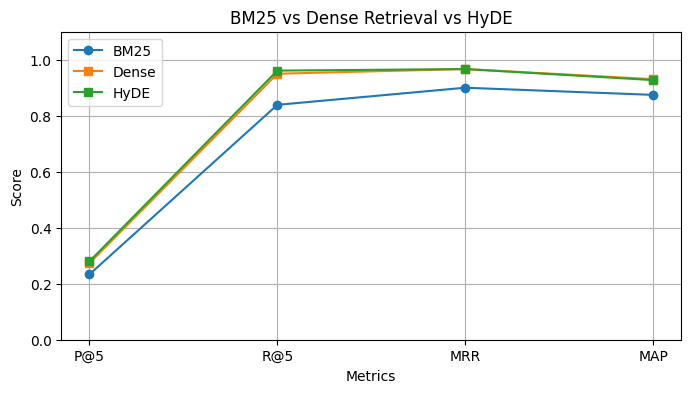

In [15]:
# 시각화
import matplotlib.pyplot as plt

metrics = ['P@5', 'R@5', 'MRR', 'MAP']
bm25_vals = [bm25_metrics['P@k'], bm25_metrics['R@k'], bm25_metrics['MRR'], bm25_metrics['MAP']]
dense_vals = [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']]
hyde_vals = [hyde_metrics['P@k'], hyde_metrics['R@k'], hyde_metrics['MRR'], hyde_metrics['MAP']]

x = range(len(metrics))

plt.figure(figsize=(8, 4))
plt.plot(x, bm25_vals, marker='o', label='BM25')
plt.plot(x, dense_vals, marker='s', label='Dense')
plt.plot(x, hyde_vals, marker='s', label='HyDE')
plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('BM25 vs Dense Retrieval vs HyDE')
plt.legend()
plt.grid()
plt.show()

##### HyDE의 역할과 효과
- HyDE는 쿼리를 “의미가 풍부한 가상문서”로 확장
- Dense가 이미 강력한 경우:
    - 성능을 보완하거나 유지
    - 항상 큰 폭의 개선을 보장하지는 않음
- 하지만 쿼리가 짧거나 모호한 경우, HyDE의 효과는 더욱 커질 가능성 있음

- Dense Retrieval은 의미 기반 검색의 기본 선택지
- HyDE는 다음 상황에서 특히 유용:
    - 짧고 추상적인 쿼리
    - 질문형 질의
    - Recall 개선이 중요한 경우
- 실서비스에서는: Dense + (HyDE / BM25 / Rerank) 조합이 가장 현실적인 접근